# Business Context

## Implementing a RAG System for PowerBI Documentation

**Description**

In the current data-driven landscape, organizations increasingly rely on powerful analytics tools like Power BI to derive insights and make informed decisions. However, many analysts struggle with the complexity and breadth of Power BI’s official documentation. The extensive resources often lead to confusion, causing users to misinterpret features or overlook essential functionalities. This challenge can result in inefficient data analysis, wasted time, and missed opportunities for actionable insights. Consequently, analysts may not fully leverage the capabilities of Power BI, stifling potential business growth and impact.

# Objective

To address these challenges, we propose implementing a Retrieval-Augmented Generation (RAG) system specifically designed for Power BI. This system will enable analysts to formulate questions using natural language and retrieve concise, relevant answers directly from the official documentation. By facilitating better access to critical information, we aim to enhance the operational efficiency of analysts and empower them to utilize Power BI to its fullest potential.

The RAG application will simplify interactions with Power BI documentation, allowing users to inquire about specific features, functions, or best practices and receive clear explanations in real-time. By improving understanding and accessibility to the tool, analysts will be able to make quicker, data-driven decisions that lead to a significant business impact.

# Conclusion


Upon completing this project, you will have the capability to develop RAG based applications. These tools will enable developers to save time by poring over technical documentations and manuals and leading to faster, more accurate responses. This project will also provide you with valuable skills and experience that can be applied to a range of real-world business challenges and domains.



# Implementation

# Installation and Importing Libraries
1. Required installations: openai==1.66.3, tiktoken==0.9.0, pypdf==5.4.0, langchain==0.3.20, langchain-community==0.3.19, langchain-chroma==0.2.2, langchain-openai==0.3.9, chromadb==0.6.3 (3 marks)
2. Import all necessary libraries: time, datetime, chromadb, OpenAI, RecursiveCharacterTextSplitter, PyPDFDirectoryLoader, Document, OpenAIEmbeddings, Chroma (3 marks)

In [ ]:
# import os
from google.colab import userdata
openai_api_key = userdata.get('OPENAI_API_KEY')

In this section, we install and import libraries required to run the notebook:

- The `openai` package provides the official OpenAI API client for accessing models like GPT-4, Whisper, DALL·E, including its embedding models

- The `tiktoken`	library provides access to OpenAI's tokenizer models, crucial for chunking and token counting

- The `pypdf` library parses and extracts text from PDF files — useful for document ingestion

- LangChain is a GenAI framework to build applications with LLMs using chains and agents.
  - `langchain` is the core library that provides access to various LangChain abstractions
  - `langchain-community` provides access to 3rd-party integrations (e.g., different vector stores, tools)
  - `langchain-chroma` provides specific integration to use ChromaDB as the vector store backend in LangChain
  - `langchain-openai` module provides a plug-in interface for LangChain to call OpenAI's LLMs using standardized interface

- `chromadb` library provides access to ChromaDB vector database, which is a fast, vector database optimized for retrieval in RAG systems

In [ ]:
# Installing the required libraries
!pip install -q numpy \
                openai \
                tiktoken \
                pypdf \
                langchain \
                langchain-community \
                langchain-chroma \
                langchain-openai \
                chromadb


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 3.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 310.5/310.5 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 78.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.8/19.8 MB 59.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.2/284.2 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 62.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 444.0/444.0 kB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.3/103.3 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 93.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 4.6 MB/s eta 0:

**Importing the Libraries**

The following code imports the necessary modules and libraries to set up a Retrieval-Augmented Generation (RAG) system using OpenAI, LangChain, and ChromaDB

In [ ]:
# Importing the standard Libraries
import time                           # For measuring execution time or adding delays
from datetime import datetime         # For handling timestamps and datetime operations
import zipfile

# ChromaDB Vector Database
import chromadb  # Chroma: a local-first vector database for storing and querying document embeddings

# OpenAI SDK
from openai import OpenAI # Official OpenAI Python SDK (v1.x) for interacting with models like GPT-4

# LangChain Utilities
# RecursiveCharacterTextSplitter intelligently breaks long text into smaller chunks with some overlap, preserving context.
from langchain.text_splitter import RecursiveCharacterTextSplitter

# Loads all PDF files from a directory and extracts text from each.
from langchain_community.document_loaders import PyPDFDirectoryLoader

# Base class representing a document in LangChain; useful for downstream chaining and processing.
from langchain_core.documents import Document

# Embeddings and Vector Store
# Generates vector embeddings using OpenAI’s embedding models (e.g., `text-embedding-3-small`)
from langchain_openai import OpenAIEmbeddings

# Integration for using Chroma as the vector store within LangChain’s ecosystem
from langchain_chroma import Chroma

In [ ]:
# Hide warnings/logs from Chroma
# This code mutes the following telemetry error in ChromaDB:
# ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
import logging
logging.getLogger("chromadb").setLevel(logging.CRITICAL)

In [ ]:
# Accessing environment variables via Colab Secrets
from google.colab import userdata

# Set the OpenAI key in Colab Secrets
openai_api_key = userdata.get('OPENAI_API_KEY') # Replace with the appropriate secret key name

# Refer to the content page present at the top of module for accessing the Open AI API_KEY from Olympus platform
# The following code sets up the OpenAI client instance with the API Key and the API Endpoint
client = OpenAI(
    api_key = openai_api_key,
    base_url = "https://xxxxxxxxxxxx/openai/v1" # OpenAI Endpoint Base URL
)

# GPT-4o-mini will be the primary model used in this notebook
model_name = 'gpt-4o-mini'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Creating Vector Database
1. PDF folder setup and PyPDFDirectoryLoader initialization (3 marks)
2. RecursiveCharacterTextSplitter configuration with tiktoken encoder (3 marks)
3. Document loading, splitting, and content inspection (3 marks)
4. ChromaDB setup, embedding model configuration, and vector store creation with batch processing (3 marks)

We will create a persistent Chroma vector database and populate this database with records from PowerBI Documentation

Each record will contain the text chunks from these documents in its vector format using an embedding model, and its metadata (e.g., source, page number).

In [ ]:
# Check if the file exists
!ls /content/drive/MyDrive/Colab_Notebooks/PowerBI.zip


/content/drive/MyDrive/Colab_Notebooks/PowerBI.zip


In [ ]:
# Unzip the dataset containing the PowerBI Documentation in to the PowerBIDoc directory
with zipfile.ZipFile('/content/drive/MyDrive/Colab_Notebooks/PowerBI.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/drive/MyDrive/Colab_Notebooks/PowerBIDoc')



The following code loads the pdf document from the given folder location, chunks the documents.

In [ ]:
# Set the directory where PDF files are stored
pdf_folder_location = "/content/drive/MyDrive/Colab_Notebooks/PowerBIDoc"

# Initialize a PDF loader to load all PDF documents in the directory
pdf_loader = PyPDFDirectoryLoader(pdf_folder_location)

# Initialize a text splitter based on token counts using OpenAI’s tokenizer ('cl100k_base')
# - chunk_size: maximum size of each chunk (in tokens)
# - chunk_overlap: number of overlapping tokens between chunks to preserve context
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    encoding_name='cl100k_base',  # OpenAI tokenizer for accurate token count
    chunk_size=512,               # Limit each chunk to 512 tokens
    chunk_overlap=16              # Keep 16-token overlap between consecutive chunks
)

# Load the PDF documents and split them into chunks using the text splitter
powerbi_chunks = pdf_loader.load_and_split(text_splitter)

The chunks are stored in a `list` data structure

In [ ]:
# Data type of the chunks
type(powerbi_chunks)

list

In [ ]:
# length of the resulting chunks
len(powerbi_chunks)

407

The chunks are stored within LangChain's [Document class](https://python.langchain.com/api_reference/core/documents/langchain_core.documents.base.Document.html) which contains the `metadata` and the `page_content` attributes.

In [ ]:
# Chunks are stored within LangChain's Document class
powerbi_chunks[0]

Document(metadata={'producer': 'Adobe Acrobat Pro 10.1.16', 'creator': 'Adobe Acrobat Pro 10.1.16', 'creationdate': '2016-06-13T10:18:21-04:00', 'author': 'Joan', 'moddate': '2016-06-13T21:13:38-04:00', 'title': '', 'source': '/content/drive/MyDrive/Colab_Notebooks/PowerBIDoc/Introducing_Power_BI.pdf', 'total_pages': 407, 'page': 0, 'page_label': '1'}, page_content='Introducing\nMicrosoft \nPower BI\nAlberto Ferrari and Marco Russo')

In [ ]:
# Let's define the ChromaDB collection name to store the chunks
powerbi_collection = 'powerbi_db'

This following code sets up the OpenAI embedding model `text-embedding-3-small` and initializes a persistent ChromaDB client to store and retrieve document embeddings in a local directory.

In [ ]:
# Instantiate the OpenAI embedding model
embedding_model = OpenAIEmbeddings(
    api_key = openai_api_key, # OpenAI API key
    base_url = "https://xxxxxxxxxxxx/openai/v1", # OpenAI API Endpoint
    model = 'text-embedding-3-small' # OpenAI's lightweight and cost-effective embedding model
)

We first instantiate a Chroma client to interact and store the vector embeddings.

Chroma provides two ways to initialize a client:
* `chromadb.Client()` - an in-memory client (everything is lost when the script ends/ runtime is restarted)
* `chromadb.PersistentClient()` - a persistent client that saves data to disk
The PersistentClient() class creates a client that stores all vector collections, embeddings, and metadata on disk. It uses SQLite databases as the storage backend by default and ensures that the data survives even after the Python process exits or the system reboots.




In [ ]:
# Initialize a persistent Chroma client
# The following code persists the data in the local disk

chromadb_client = chromadb.PersistentClient(
    path="./powerbi_db", # Local directory where vector database will be stored
 )

In [ ]:
# Pinging the database client to check if the connection is alive
# the heartbeat method returns the current time in nanoseconds and is generally used to check if the server is alive
chromadb_client.heartbeat()

1756983266577600775

In [ ]:
# Confirming database is empty
chromadb_client.count_collections()

0

Creating a vectorstore collection for the Chroma collection `powerbi_collection`.

Chroma collections store your embeddings, documents, and any additional metadata. Collections index the embeddings and documents, and enable efficient retrieval and filtering.

In [ ]:
# Instantiate a Chroma vector store to store and retrieve document embeddings
vectorstore = Chroma(
    collection_name = powerbi_collection,               # Name of the Chroma collection to group related embeddings
    collection_metadata = {"hnsw:space": "cosine"},     # Use cosine similarity for nearest-neighbor search (HNSW index)
    embedding_function = embedding_model,               # Embedding model used to convert text into vectors
    client = chromadb_client,                           # Persistent Chroma client initialized earlier
    persist_directory = "./powerbi_db"                  # Directory where Chroma will persist its data
)

In [ ]:
# confirming collection creation
chromadb_client.list_collections()

[Collection(name=powerbi_db)]

In [ ]:
# Confirming database has been populated with the collection
chromadb_client.count_collections()

1

Let's add documents to the created *powerbi_db* collection in the vector store in batches.

The following code uses the `.add_documents` method to add the chunks to the database in batches of 500 for efficient processing.

In [ ]:
# Batch 500 chunks to send to the API at a time, pausing execution for 30 seconds afterward
i = 0 # Initialize the starting index for the chunks

while i < len(powerbi_chunks): # Iterate while the index is less than the total number of chunks
    vectorstore.add_documents( # Add documents to the vector store in batches of 500
        documents=powerbi_chunks[i:i+500], # Get the current batch of 500 chunks
        ids=["text_" + str(i) for i in range(i, i+500)] # Assign unique IDs to each chunk in the batch
    )

    i += 500 # Move to the next batch by incremening the index by 500
    time.sleep(30) # Pause for 30 seconds to avoid rate limiting issues with the vector store

# CRUD Operations on the Vector Database
1. Vector store initialization and collection setup (2 marks)
2. Read operations: count, peek, get, and retriever configuration (3 marks)
3. Create/Update operations: document updates with metadata (3 marks)
4. Delete operations: removing records from vector store (2 marks)

## **READ**

Once the database is created, the stored entries can be retrieved by initializing a new Chroma instance (denoted as **vectorstore_persisted** to distinguish between creation and read operations) and directing it to the persistent storage directory containing the document embeddings.

In [ ]:
vectorstore_persisted = Chroma(
    collection_name = powerbi_collection,
    collection_metadata = {"hnsw:space": "cosine"},
    embedding_function = embedding_model,
    client = chromadb_client,
    persist_directory = "./powerbi_db"
)

There are two valuable types of READ operations in vector databases:

1. **Inspecting individual records**
2. **Retrieving relevant records based on a user query**

Let us look at each in turn.

**Inspecting individual records**

The following code retrieves an existing collection `powerbi_collection` (analogous to a table in relational databases) from the ChromaDB instance

In [ ]:
# Define the chroma collection
collection = chromadb_client.get_collection(powerbi_collection)

In [ ]:
# Count the number of records in the collection
collection.count()

407

In [ ]:
# Inspect into the first record using the .peek() method
collection.peek(1)

{'ids': ['text_0'],
 'embeddings': array([[-0.0141233 , -0.03104495,  0.0387464 , ..., -0.00077508,
          0.00032513,  0.01716083]]),
 'documents': ['Introducing\nMicrosoft \nPower BI\nAlberto Ferrari and Marco Russo'],
 'uris': None,
 'included': ['metadatas', 'documents', 'embeddings'],
 'data': None,
 'metadatas': [{'creator': 'Adobe Acrobat Pro 10.1.16',
   'creationdate': '2016-06-13T10:18:21-04:00',
   'total_pages': 407,
   'page_label': '1',
   'page': 0,
   'source': '/content/drive/MyDrive/Colab_Notebooks/PowerBIDoc/Introducing_Power_BI.pdf',
   'title': '',
   'producer': 'Adobe Acrobat Pro 10.1.16',
   'moddate': '2016-06-13T21:13:38-04:00',
   'author': 'Joan'}]}

In [ ]:
len(collection.peek(1)['embeddings'][0])

1536

In [ ]:
# Inspect a specific record in the collection
collection.get(
    ids = ['text_0']
)

{'ids': ['text_0'],
 'embeddings': None,
 'documents': ['Introducing\nMicrosoft \nPower BI\nAlberto Ferrari and Marco Russo'],
 'uris': None,
 'included': ['metadatas', 'documents'],
 'data': None,
 'metadatas': [{'title': '',
   'page': 0,
   'creationdate': '2016-06-13T10:18:21-04:00',
   'creator': 'Adobe Acrobat Pro 10.1.16',
   'producer': 'Adobe Acrobat Pro 10.1.16',
   'total_pages': 407,
   'source': '/content/drive/MyDrive/Colab_Notebooks/PowerBIDoc/Introducing_Power_BI.pdf',
   'page_label': '1',
   'moddate': '2016-06-13T21:13:38-04:00',
   'author': 'Joan'}]}

**Retrieving relevant records based on a user query**

The primary function of the vector database is to retrieve relevant records based on user queries and to facilitate this process, we implement a retriever that utilizes the query embeddings to query the database.

The following code uses HNSW algorithm to calculate the nearest neighbors for the user query and returns the corresponding documents from the database.

In [ ]:
# Create a retriever interface from the vector store
retriever = vectorstore_persisted.as_retriever(
    search_type = 'similarity',             # Use the default method based on semantic similarity
    search_kwargs = {'k': 5}                # Retrieve top 5 most similar chunks
)

# Define a sample user query
user_query = "What is power bi"

The following code performs the similarity search based on the user query by using the `.invoke()` method.

In [ ]:
# Perform similarity search to returns top 5 document chunks based on sample user query
retriever.invoke(user_query)

[Document(id='text_23', metadata={'title': '', 'page': 23, 'moddate': '2016-06-13T21:13:38-04:00', 'total_pages': 407, 'author': 'Joan', 'creator': 'Adobe Acrobat Pro 10.1.16', 'creationdate': '2016-06-13T10:18:21-04:00', 'producer': 'Adobe Acrobat Pro 10.1.16', 'page_label': '24', 'source': '/content/drive/MyDrive/Colab_Notebooks/PowerBIDoc/Introducing_Power_BI.pdf'}, page_content='6 C H A P T E R  1  |  Introducing Power BI \n \nFortunately, David heard about an interesting \ntool called Power BI that Microsoft created in \n2015 that might be helpful toward creating a \ncollaborative environment in which any \nstakeholder of the budgeting process can share \nhis findings with others, working together on the \ngoal. But, at this point, the name and maybe a \nmarketing video is all that David knows about \nPower BI. \nDriven by curiosity, he navigates to \nwww.powerbi.com\n and starts down his learning \npath. Figure 1-2 depicts the welcome page of \nthe Power BI website. \n \nFigure 1

## **UPDATE**

Updating any individual record on one or more fields associated with it.

The `update_document` method updates one document by ID.

In [ ]:
# Define the chunk index that needs to be updated
record_index_for_update = 1

# Display the record for the given index
vectorstore_persisted.get(
    ids = [f'text_{record_index_for_update}']
)

{'ids': ['text_1'],
 'embeddings': None,
 'documents': ['PUBLISHED BY \nMicrosoft Press \nA division of Microsoft Corporation \nOne Microsoft Way \nRedmond, Washington 98052-6399 \nCopyright © 2016 by Microsoft Corporation \nAll rights reserved. No part of the contents of \nthis book may be reproduced or transmitted in \nany form or by any means without the written \npermission of the publisher. \nISBN: 978-1-5093-0228-4 \nMicrosoft Press books are available through \nbooksellers and distributors worldwide. If you \nneed support related to this book, email \nMicrosoft Press Support at \nmspinput@microsoft.com. Please tell us what \nyou think of this book at http://aka.ms/tellpress. \nThis book is provided “as-is” and expresses the \nauthor’s views and opinions. The views, opinions \nand information expressed in this book, \nincluding URL and other Internet website \nreferences, may change without notice. \nSome examples depicted herein are provided for \nillustration only and are ficti

In [ ]:
powerbi_chunks[record_index_for_update].page_content

'PUBLISHED BY \nMicrosoft Press \nA division of Microsoft Corporation \nOne Microsoft Way \nRedmond, Washington 98052-6399 \nCopyright © 2016 by Microsoft Corporation \nAll rights reserved. No part of the contents of \nthis book may be reproduced or transmitted in \nany form or by any means without the written \npermission of the publisher. \nISBN: 978-1-5093-0228-4 \nMicrosoft Press books are available through \nbooksellers and distributors worldwide. If you \nneed support related to this book, email \nMicrosoft Press Support at \nmspinput@microsoft.com. Please tell us what \nyou think of this book at http://aka.ms/tellpress. \nThis book is provided “as-is” and expresses the \nauthor’s views and opinions. The views, opinions \nand information expressed in this book, \nincluding URL and other Internet website \nreferences, may change without notice. \nSome examples depicted herein are provided for \nillustration only and are fictitious. No real'

In [ ]:


# The following code updates the record for the given index
# The code creates a new Document object containing the same page_content as the original chunk
# But inserts a new metadata
vectorstore_persisted.update_document(
    document_id = 'text_' + str(record_index_for_update),
    document = Document(
        page_content = powerbi_chunks[record_index_for_update].page_content,
        metadata = {"creator": "johndoe"}
    )
)

# An additional entry has been added to the metadata field
vectorstore_persisted.get(
    ids = [f'text_{record_index_for_update}']
)

{'ids': ['text_1'],
 'embeddings': None,
 'documents': ['PUBLISHED BY \nMicrosoft Press \nA division of Microsoft Corporation \nOne Microsoft Way \nRedmond, Washington 98052-6399 \nCopyright © 2016 by Microsoft Corporation \nAll rights reserved. No part of the contents of \nthis book may be reproduced or transmitted in \nany form or by any means without the written \npermission of the publisher. \nISBN: 978-1-5093-0228-4 \nMicrosoft Press books are available through \nbooksellers and distributors worldwide. If you \nneed support related to this book, email \nMicrosoft Press Support at \nmspinput@microsoft.com. Please tell us what \nyou think of this book at http://aka.ms/tellpress. \nThis book is provided “as-is” and expresses the \nauthor’s views and opinions. The views, opinions \nand information expressed in this book, \nincluding URL and other Internet website \nreferences, may change without notice. \nSome examples depicted herein are provided for \nillustration only and are ficti

## **DELETE**

In [ ]:
##  The following line deletes records and should be used with caution
vectorstore.delete(ids=['text_1'])
vectorstore_persisted.delete(ids=['text_1'])

In [ ]:
# Check that the record was deleted
vectorstore.get(
    ids = ['text_1']
)

{'ids': [],
 'embeddings': None,
 'documents': [],
 'uris': None,
 'included': ['metadatas', 'documents'],
 'data': None,
 'metadatas': []}

# RAG System for PowerBI Documentation

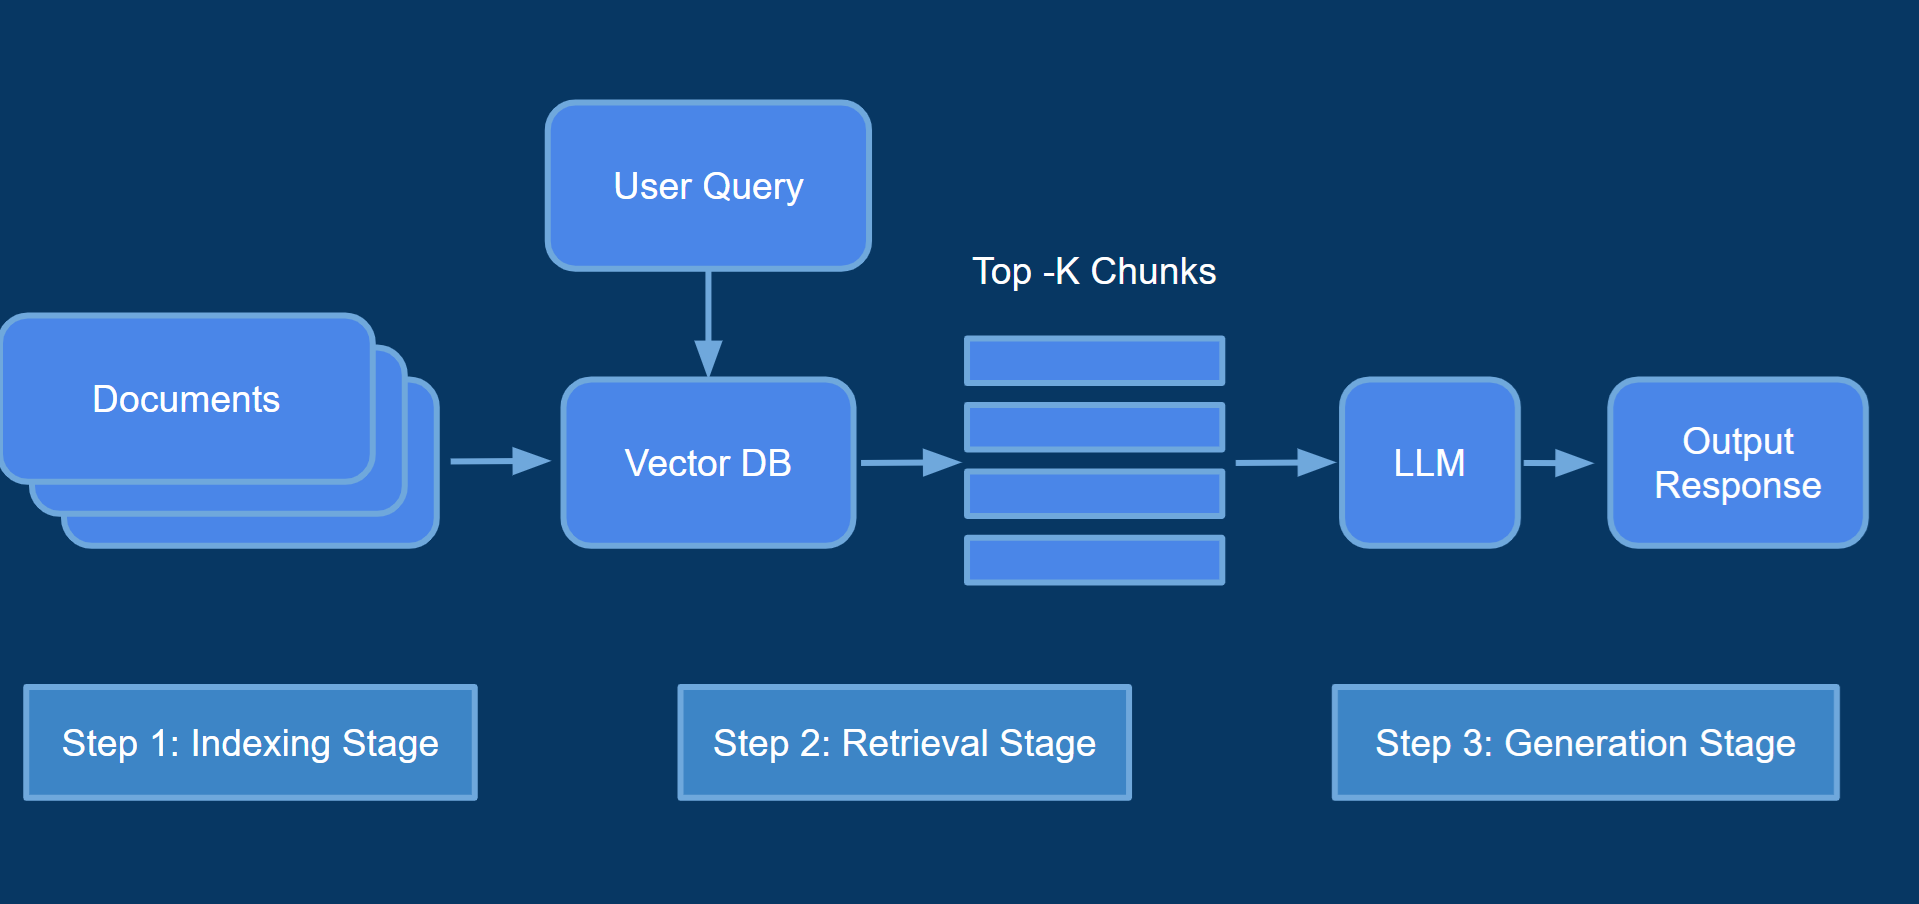

A typical RAG implementation consists of the following stages:
* Indexing Stage
* Retrieval Stage
* Generation Stage

| Stage          | Key Activities                                        | Role in RAG                              |
| -------------- | ----------------------------------------------------- | ---------------------------------------- |
| **Indexing**   | Chunking · Embedding · Storing                        | Prepares data for efficient retrieval    |
| **Retrieval**  | Query embedding · Similarity search   | Consolidates relevant context            |
| **Generation** | Prompt construction · LLM generation | Produces final response grounded in data |


Let's now put together the RAG pipeline using these stages.

**Note** that the **Indexing Stage** has already been performed in the previous sections.

## Retrieval Stage

**Retrieving Relevant Documents**

The following codes performs the Retrieval stage in the RAG pipeline.

Let's define a sample user query to test the RAG pipeline

In [ ]:
user_query = "How can I use aggregagation features in Power BI?"

Retrieve the relevant chunks from the documents based on the `user_query`.

Note we're accessing the `retriever` that has been defined already and we're not repeating the text processing pipeline performed earlier.

In [ ]:
relevant_document_chunks = retriever.invoke(user_query)

In [ ]:
len(relevant_document_chunks)

5

In [ ]:
# Inspecting the first document
for document in relevant_document_chunks:
    print(document.page_content.replace("\t", " "))
    break

347 C H A P T E R  8  |  Using Microsoft Power BI in your  
 company 
 
 
Figure 8-10: A PivotTable in Excel that is connected 
to t
he Sales 2015 - Analytics model in Power BI by 
using Analyze In Excel. 
Excel ignores that the nature of the sales 
columns is that of numbers that can be 
aggregated. This information must be provided 
by using explicit measures, such as those 
demonstrated in Chapter 6. For example, Figure 
8-11 shows a PivotTable obtained by using 
Analyze In Excel on the Budget data model


## Generation Stage

This section will perform the **Generation** stage of the RAG pipeline.

We will pass the relevant context chunks to the LLM, along with the system message and user message via a prompt template.

These are then passed to the LLM to compose an appropriate response to the user's query.


### Prompt Template

Defining the system message for the RAG chatbot with the appopriate role, context and the relevant instructions.

In [ ]:
qna_system_message = """
You are an assistant that helps analysts and business users understand and work with Power BI.

## Input Structure
- **Context**
  Enclosed between `<Context>` and `</Context>`.
  Contains excerpts from Power BI’s official documentation that are relevant to the query.

- **Question**
  Enclosed between `<Question>` and `</Question>`.
  Contains the user’s natural language query.

## Instructions for Answering
- Use **only** the information inside `<Context> ... </Context>` to answer.
- Provide a **clear, concise, and practical** explanation as if speaking to an analyst.
- If the answer involves a **formula, function, or step-by-step instructions**, format it appropriately (e.g., code block, numbered steps).
- Do not mention or reference the context in your final answer.
- Do not invent or guess information outside the given context.
- If no answer is found in the context, reply with:
  **“I don’t know.”**
"""

The following user message prompt template provides the relevant chunks and the user query within the `context` and `question` placeholders respectively.

In [ ]:
qna_user_message_template = """
<Context>
Here are some documents that are relevant to the question mentioned below.
{context}
</Context>

<Question>
{question}
</Question>
"""

### Generating the Response

In [ ]:
user_query = "How can I use aggregagation features in Power BI?"

relevant_document_chunks = retriever.invoke(user_query)
context_list = [d.page_content for d in relevant_document_chunks]
context_for_query = "\n---\n".join(context_list)

prompt = [
    {'role': 'developer', 'content': qna_system_message},
    {'role': 'user', 'content': qna_user_message_template.format(
         context=context_for_query,
         question=user_query
        )
    }
]

try:
    response = client.chat.completions.create(
        model=model_name,
        messages=prompt,
        temperature=0
    )

    prediction = response.choices[0].message.content.strip()
except Exception as e:
    prediction = f'Sorry, I encountered the following error: \n {e}'

print(prediction)

To use aggregation features in Power BI, you can follow these steps:

1. **Select Fields**: When creating a report, choose the fields you want to include. For example, if you want to analyze sales data, you might select fields like "Brand" and "Sale 2015".

2. **Understand Summarization**: In the Fields pane, fields that can be aggregated will display a summarization icon (sigma). For instance, "Sale 2015" will show this icon, indicating that it can be summed.

3. **Create Visualizations**: Drag the selected fields into your report. For example, dragging "Brand" (which slices data) and "Sale 2015" (which aggregates data) will create a default visualization that shows the sum of sales for each brand.

4. **Use DAX for Custom Measures**: If you need specific aggregations beyond the standard options (like sum, average, or count distinct), you can create custom measures and calculated columns using DAX (Data Analysis Expressions). This allows for more complex calculations and aggregations.

# Putting it all together - Power BI RAG Q&A Chatbot

We'll now put together the relevant codes for the RAG pipeline into a file named `rag-chat.py` to create a basic command-line chat interface which can run via  the terminal.

This naive RAG implementation illustrates how document Q&A could be automated for any domain.

The following codes use the `%%writefile` magic command specific to Google Colab, which allows the content of a cell to be written directly into a file on the virtual machine's disk.

This allows for the creation of scripts, configuration files, or data files within the Colab environment. These files are available during the Colab runtime and are deleted when the runtime is stopped or deleted.

The `!python` shell command can be used to execute a Python script (.py files) or commands within the Colab environment.

In [ ]:
import os
# Set the OpenAI API key as an environment variable.
# This allows libraries (like the OpenAI SDK) to automatically detect the key without hardcoding it in the script.
os.environ['openai_api_key'] = openai_api_key

In [ ]:
%%writefile rag-chat.py
import os
import chromadb

from openai import OpenAI

from langchain_openai import OpenAIEmbeddings
from langchain_chroma import Chroma
import logging
logging.getLogger("chromadb").setLevel(logging.CRITICAL)

from google.colab import userdata

model_name = 'gpt-4o-mini'
powerbi_collection = 'powerbi_db'
openai_api_key = os.environ.get('openai_api_key')

client = OpenAI(
    api_key=openai_api_key,
    base_url="https://xxxxxxxxxxxx/openai/v1"
)

embedding_model = OpenAIEmbeddings(
    api_key=openai_api_key,
    base_url="",
    model='text-embedding-3-small'
)

chromadb_client = chromadb.PersistentClient(
    path="./powerbi_db"
)

vectorstore_persisted = Chroma(
    collection_name=powerbi_collection,
    collection_metadata={"hnsw:space": "cosine"},
    embedding_function=embedding_model,
    client=chromadb_client,
    persist_directory="./powerbi_db"
)

retriever = vectorstore_persisted.as_retriever(
    search_type='similarity',
    search_kwargs={'k': 5}
)

qna_system_message = """
You are an assistant that helps analysts and business users understand and work with Power BI.

## Input Structure
- **Context**
  Enclosed between `<Context>` and `</Context>`.
  Contains excerpts from Power BI’s official documentation that are relevant to the query.

- **Question**
  Enclosed between `<Question>` and `</Question>`.
  Contains the user’s natural language query.

## Instructions for Answering
- Use **only** the information inside `<Context> ... </Context>` to answer.
- Provide a **clear, concise, and practical** explanation as if speaking to an analyst.
- If the answer involves a **formula, function, or step-by-step instructions**, format it appropriately (e.g., code block, numbered steps).
- Do not mention or reference the context in your final answer.
- Do not invent or guess information outside the given context.
- If no answer is found in the context, reply with:
  **“I don’t know.”**
"""

qna_user_message_template = """
<Context>
Here are some documents that are relevant to the question mentioned below.
{context}
</Context>

<Question>
{question}
</Question>
"""

def respond(user_query):
    relevant_document_chunks = retriever.invoke(user_query)
    context_list = [d.page_content for d in relevant_document_chunks]
    context_for_query = "\n---\n".join(context_list)

    prompt = [
        {'role': 'developer', 'content': qna_system_message},
        {
            'role': 'user', 'content': qna_user_message_template.format(
             context=context_for_query,
             question=user_query)
        }
    ]

    try:
        response = client.chat.completions.create(
            model=model_name,
            messages=prompt,
            temperature=0
        )

        answer = response.choices[0].message.content.strip()
    except Exception as e:
        answer = f'Sorry, I encountered the following error: \n {e}'

    return answer

def main():
    """
    Runs the main interactive loop for the Q&A system.

    This function initializes the conversation history, continuously prompts
    the user for queries, processes the queries using the `respond` function,
    and displays the assistant's responses. It also maintains the
    conversation history for context.

    Args:
        None

    Returns:
        None
    """

    # 1. Initialize conversation history.
    # This list stores the conversation between the user and the assistant.
    # It starts with a system message introducing the assistant's role.
    conversation_history = [
        {'role': 'developer', 'content': 'You are an assistant that helps analysts and business users understand and work with Power BI'}

        ]

    # 2. Enter the interactive loop.
    # The loop continues until the user enters 'q' to quit.
    while True:
        # 2.1 Get user input.
        # Prompt the user to enter a query and store it in `user_query`.
        user_query = input("User (type q to quit): ")

        # 2.2 Check for quit condition.
        # If the user enters 'q', break out of the loop.
        if user_query == 'q':
            break

        # 2.3 Process the query and get the answer.
        # Call the `respond` function to process the user query and get the answer.
        answer = respond(user_query)

        # 2.4 Update conversation history.
        # Add the user's query and the assistant's answer to the conversation history.
        conversation_history.append({'role': 'user', 'content': user_query})
        conversation_history.append({'role': 'assistant', 'content': answer})

        # 2.5 Display the assistant's answer.
        # Print the assistant's answer to the console.
        print(f"Assistant: {answer}")

if __name__ == "__main__":
    main()

Overwriting rag-chat.py


The following are some **test queries** that can be used to test the RAG pipeline:
- What are the sub-limits applicable to robotic surgeries, and which robotic procedures are exempt from these sub-limits?

- How are pre-hospitalization and post-hospitalization expenses covered in relation to Day Care Treatments and Modern Treatments, and what is the maximum duration for which these expenses are reimbursed?

- How does the policy cover HIV/AIDS related hospitalization expenses, what sub-limits apply, and which lifestyle diseases related to HIV/AIDS are explicitly excluded?

- In case of a claim involving multiple illnesses or injuries within the same policy year, how does the policy handle sum insured restoration and claim settlement priority under the Re-fill Benefit?

Run the script using the `!python` shell command.

In [ ]:
!python rag-chat.py

User (type q to quit): What is Power BI
Assistant: Power BI is a cloud service created by Microsoft that provides tools for data analysis and gaining insights from data. It allows users to build dashboards, which consist of datasets, reports, and visualizations. Power BI can be used with or without Excel, and it offers a mobile experience along with the ability to load data from various cloud sources. Users can create visualizations through natural-language queries, Quick Insights, or full reports, and enhance reports with text boxes, shapes, and pictures. There are two main experiences for using Power BI: Power BI Desktop, a Windows application for more advanced tasks, and the web-based Power BI service.
User (type q to quit): q
